# SVM Poisoning Defenses
This notebook evaluates Brute Force RONI, Hybrid RONI (using Influence Functions to filter the top 40% most suspicious points then uses Brute-Force), and Data Sanitization defenses against SVM poisoning attacks on 2D Gaussian and MNIST datasets.
We inject `NUMBER_OF_POISON_INSTANCES = 10` poison points in each experiment and print validation/test loss and error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import time
import warnings
warnings.filterwarnings('ignore')

# Import functions from the existing svm_poisoning.py
from svm_poisoning import (
    LinearKernel, RBFKernel, PolynomialKernel, train_svm, poisoning_attack, 
    get_svm_info, load_mnist, get_binary_problem, SEED
)
np.random.seed(SEED)

NUMBER_OF_POISON_INSTANCES = 10


In [2]:
def print_stats(name, clf, X_val, y_val, X_test=None, y_test=None):
    print(f"--- Stats for {name} ---")
    val_loss = np.mean(np.maximum(0, 1 - y_val * clf.decision_function(X_val)))
    val_err = np.mean(clf.predict(X_val) != y_val)
    print(f"Validation Hinge Loss : {val_loss:.4f}")
    print(f"Validation Error      : {val_err:.4f}")
    test_loss, test_err = None, None
    
    if X_test is not None:
        test_loss = np.mean(np.maximum(0, 1 - y_test * clf.decision_function(X_test)))
        test_err = np.mean(clf.predict(X_test) != y_test)
        print(f"Test Hinge Loss       : {test_loss:.4f}")
        print(f"Test Error            : {test_err:.4f}")
    print()
    return val_loss, val_err, test_loss, test_err

def plot_defense_results(results, title):
    labels = list(results.keys())
    val_errs = [results[k]['val_err'] for k in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    has_test = all('test_err' in results[k] and results[k]['test_err'] is not None for k in labels)
    
    min_err = min(val_errs)
    max_err = max(val_errs)
    
    if has_test:
        test_errs = [results[k]['test_err'] for k in labels]
        
        colors = ['red' if 'Poison' in label else 'skyblue' for label in labels]
        ax.bar(x - width/2, val_errs, width, label='Validation Error', color=colors, edgecolor='black')
        ax.bar(x + width/2, test_errs, width, label='Test Error', color='salmon', edgecolor='black')
        
        min_err = min(min_err, min(test_errs))
        max_err = max(max_err, max(test_errs))
    else:
        colors = ['red' if 'Poison' in label else 'skyblue' for label in labels]
        ax.bar(x, val_errs, width, label='Validation Error', color=colors, edgecolor='black')
        
    ax.set_ylabel('Classification Error')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.legend()
    
    if min_err > 0:
        ax.set_ylim(bottom=max(0.0, min_err * 0.85), top=max_err * 1.05)
        
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [3]:
def brute_force_roni_defense(X_train, y_train, X_val, y_val, kernel, C=1.0, threshold_k=1.5):
    """
    Implements RONI (Reject On Negative Impact) using brute-force leave-one-out.
    """
    n = len(X_train)
    clf_clean = train_svm(X_train, y_train, C, kernel)
    L_clean = np.mean(np.maximum(0, 1 - y_val * clf_clean.decision_function(X_val)))
    
    impacts = np.zeros(n)
    for i in range(n):
        X_minus_i = np.delete(X_train, i, axis=0)
        y_minus_i = np.delete(y_train, i)
        clf_i = train_svm(X_minus_i, y_minus_i, C, kernel)
        L_without_i = np.mean(np.maximum(0, 1 - y_val * clf_i.decision_function(X_val)))
        impacts[i] = L_clean - L_without_i
        
    mean_impact = np.mean(impacts)
    std_impact = np.std(impacts)
    threshold = mean_impact + threshold_k * std_impact
    suspicious_indices = np.where(impacts > threshold)[0]
    
    X_sanitized = np.delete(X_train, suspicious_indices, axis=0)
    y_sanitized = np.delete(y_train, suspicious_indices)
    
    return X_sanitized, y_sanitized, suspicious_indices, impacts

def _compute_approx_impacts(X_train, y_train, X_val, y_val, kernel, C=1.0):
    """
    Computes Influence Functions (first-order approximation of leave-one-out)
    to get approximate impacts for all points.
    """
    n = len(X_train)
    clf = train_svm(X_train, y_train, C, kernel)
    info = get_svm_info(clf, X_train, y_train, C, attack_idx=0, kernel=kernel)
    
    alpha = info['all_alphas']
    b = info['b']
    S_indices = info['S_indices']
    X_s = info['X_s']
    y_s = info['y_s']
    n_s = len(S_indices)
    
    f_val = clf.decision_function(X_val)
    L_clean = np.mean(np.maximum(0, 1 - y_val * f_val))
    
    impacts = np.zeros(n)
    
    if n_s == 0:
        return impacts
        
    K_ss = kernel.compute(X_s, X_s)
    Q_ss = np.outer(y_s, y_s) * K_ss
    Q_ss += 1e-9 * np.eye(n_s)
    
    try:
        Q_ss_inv = np.linalg.inv(Q_ss)
    except np.linalg.LinAlgError:
        return impacts
        
    v = Q_ss_inv @ y_s
    zeta = float(y_s @ v)
    if abs(zeta) < 1e-12:
        return impacts
        
    K_val_s = kernel.compute(X_val, X_s)
    
    for i in range(n):
        if alpha[i] < 1e-8:
            impacts[i] = 0.0
            continue
            
        d_alpha_i = -alpha[i]
        
        x_i = X_train[i:i+1]
        y_i = y_train[i]
        
        K_si = kernel.compute(X_s, x_i).flatten()
        Q_si = y_s * y_i * K_si
        
        db = - (1.0 / zeta) * (np.dot(v, Q_si) - y_i) * d_alpha_i
        d_alpha_S = - Q_ss_inv @ (Q_si * d_alpha_i + y_s * db)
        
        term1 = K_val_s @ (d_alpha_S * y_s)
        term2 = db
        K_val_i = kernel.compute(X_val, x_i).flatten()
        term3 = d_alpha_i * y_i * K_val_i
        
        df_val = term1 + term2 + term3
        f_val_new = f_val + df_val
        
        L_new = np.mean(np.maximum(0, 1 - y_val * f_val_new))
        impacts[i] = L_clean - L_new

    return impacts

def hybrid_roni_defense(X_train, y_train, X_val, y_val, kernel, C=1.0, threshold_k=1.5, top_percent=0.40):
    """
    Hybrid RONI: Uses Influence Functions to filter the top 40% most suspicious points,
    then uses Brute-Force exact retraining on ONLY those candidates to get perfect accuracy.
    """
    n = len(X_train)
    
    # 1. Quick pass: Use Influence Functions to get approximate impacts for everyone
    approx_impacts = _compute_approx_impacts(X_train, y_train, X_val, y_val, kernel, C)
    
    # 2. Filter: Select the top X% most suspicious candidates
    num_candidates = max(1, int(n * top_percent))
    candidate_indices = np.argsort(approx_impacts)[::-1][:num_candidates]
    
    # 3. Exact pass: Run Brute-Force retraining ONLY on the candidates
    clf_clean = train_svm(X_train, y_train, C, kernel)
    L_clean = np.mean(np.maximum(0, 1 - y_val * clf_clean.decision_function(X_val)))
    
    exact_impacts = np.zeros(n)
    for i in candidate_indices:
        X_minus_i = np.delete(X_train, i, axis=0)
        y_minus_i = np.delete(y_train, i)
        
        clf_i = train_svm(X_minus_i, y_minus_i, C, kernel)
        L_without_i = np.mean(np.maximum(0, 1 - y_val * clf_i.decision_function(X_val)))
        
        exact_impacts[i] = L_clean - L_without_i
        
    # 4. Final Decision based on EXACT impacts
    mean_impact = np.mean(approx_impacts)
    std_impact = np.std(approx_impacts)
    threshold = mean_impact + threshold_k * std_impact
    
    # Find which of our candidates crossed the threshold using their EXACT impacts
    suspicious_candidates = [i for i in candidate_indices if exact_impacts[i] > threshold]
    
    X_sanitized = np.delete(X_train, suspicious_candidates, axis=0)
    y_sanitized = np.delete(y_train, suspicious_candidates)
    
    return X_sanitized, y_sanitized, suspicious_candidates, exact_impacts

def data_sanitization_defense(X_train, y_train, kernel, k=2.0):
    """
    Detects outliers using an Isolation Forest combined with a robust 
    Median Absolute Deviation (MAD) threshold.
    """
    from sklearn.ensemble import IsolationForest
    import numpy as np
    
    n = len(X_train)
    suspicious_indices = []
    
    classes = np.unique(y_train)
    for c in classes:
        class_indices = np.where(y_train == c)[0]
        if len(class_indices) == 0: continue
            
        X_c = X_train[class_indices]
        
        # Fit Isolation Forest
        iso = IsolationForest(random_state=42)
        iso.fit(X_c)
        
        # score_samples gives lower values for anomalies, flip it
        scores = -iso.score_samples(X_c)
        
        # Robust MAD thresholding
        median_score = np.median(scores)
        mad = np.median(np.abs(scores - median_score))
        if mad == 0: mad = 1e-6
        
        threshold = median_score + k * mad
        outliers = class_indices[scores > threshold]
        
        suspicious_indices.extend(outliers)
        
    suspicious_indices = np.array(suspicious_indices, dtype=int)
    X_sanitized = np.delete(X_train, suspicious_indices, axis=0)
    y_sanitized = np.delete(y_train, suspicious_indices)
    
    # Return 0 for distances to keep API signature consistent
    return X_sanitized, y_sanitized, suspicious_indices, np.zeros(n)


#### Defense mechanisms on MNIST dataset

In [4]:
def run_mnist_defenses(pos_digit=7, neg_digit=1, n_poison=5):
    print("\n" + "="*50)
    print(f"EXPERIMENT: MNIST ({pos_digit} vs {neg_digit})")
    print("="*50)
    
    np.random.seed(42)
    
    # 1. Generate Clean Data
    X_mnist, y_mnist = load_mnist()
    X_tr, y_tr, X_val, y_val, X_test, y_test = get_binary_problem(X_mnist, y_mnist, pos_digit, neg_digit)
    
    orig_len = len(X_tr)
    
    kernel = LinearKernel()
    C = 1.0
    
    results = {}
    
    clf_clean = train_svm(X_tr, y_tr, C, kernel)
    vloss, verr, tloss, terr = print_stats("Clean Model", clf_clean, X_val, y_val, X_test, y_test)
    results["Clean Model"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 2. Attack the Model
    # n_poison = n_poison
    print(f"\nInjecting {n_poison} poison points...")
    X_tr_poisoned = X_tr.copy()
    y_tr_poisoned = y_tr.copy()
    yc = -1
    
    pos_indices = np.where(y_tr == 1)[0]
    
    for _ in range(n_poison):
        init_idx = np.random.choice(pos_indices)
        xc_init = X_tr[init_idx].copy()
        
        res = poisoning_attack(
            X_tr_poisoned, y_tr_poisoned, X_val, y_val, yc, xc_init, kernel,
            C=C, step_size=0.05, max_iter=200, epsilon=0.01,
            gradient_sign=-1, verbose=False, print_every=0,
            bound_min=np.zeros(784), bound_max=np.ones(784)
        )
        
        X_tr_poisoned = np.vstack([X_tr_poisoned, res['xc'].reshape(1, -1)])
        y_tr_poisoned = np.concatenate([y_tr_poisoned, [yc]])
        
    clf_poisoned = train_svm(X_tr_poisoned, y_tr_poisoned, C, kernel)
    vloss, verr, tloss, terr = print_stats("Poisoned Model", clf_poisoned, X_val, y_val, X_test, y_test)
    results["Poisoned Model"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 3. Defend: Brute Force RONI
    print("\nRunning Brute Force RONI defense (leave-one-out retraining)...")
    X_bf, y_bf, s_idx, bf_impacts = brute_force_roni_defense(X_tr_poisoned, y_tr_poisoned, X_val, y_val, kernel, C, threshold_k=1.5)
    total_removed = len(s_idx)
    poison_removed = sum(1 for idx in s_idx if idx >= orig_len)
    clean_removed = sum(1 for idx in s_idx if idx < orig_len)
    print(f"[Brute Force RONI] Total Removed: {total_removed} | Poison Removed (Actual): {poison_removed}/{n_poison} | Clean Removed (Mistake): {clean_removed}/{orig_len}")
    
    clf_bf = train_svm(X_bf, y_bf, C, kernel)
    vloss, verr, tloss, terr = print_stats("Brute Force RONI", clf_bf, X_val, y_val, X_test, y_test)
    results["Brute Force RONI"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 4. Defend: Hybrid RONI (10%)
    print("\nRunning Hybrid RONI (10%) defense...")
    X_roni1, y_roni1, s_idx, impacts = hybrid_roni_defense(X_tr_poisoned, y_tr_poisoned, X_val, y_val, kernel, C, threshold_k=1.5, top_percent=0.10)
    total_removed = len(s_idx)
    poison_removed = sum(1 for idx in s_idx if idx >= orig_len)
    clean_removed = sum(1 for idx in s_idx if idx < orig_len)
    print(f"[Hybrid RONI (10%)] Total Removed: {total_removed} | Poison Removed (Actual): {poison_removed}/{n_poison} | Clean Removed (Mistake): {clean_removed}/{orig_len}")
    
    clf_roni1 = train_svm(X_roni1, y_roni1, C, kernel)
    vloss, verr, tloss, terr = print_stats("Hybrid RONI (10%)", clf_roni1, X_val, y_val, X_test, y_test)
    results["Hybrid RONI (10%)"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 5. Defend: Hybrid RONI (40%)
    print("\nRunning Hybrid RONI (40%) defense...")
    X_roni2, y_roni2, s_idx, impacts = hybrid_roni_defense(X_tr_poisoned, y_tr_poisoned, X_val, y_val, kernel, C, threshold_k=1.5, top_percent=0.40)
    total_removed = len(s_idx)
    poison_removed = sum(1 for idx in s_idx if idx >= orig_len)
    clean_removed = sum(1 for idx in s_idx if idx < orig_len)
    print(f"[Hybrid RONI (40%)] Total Removed: {total_removed} | Poison Removed (Actual): {poison_removed}/{n_poison} | Clean Removed (Mistake): {clean_removed}/{orig_len}")
    
    clf_roni2 = train_svm(X_roni2, y_roni2, C, kernel)
    vloss, verr, tloss, terr = print_stats("Hybrid RONI (40%)", clf_roni2, X_val, y_val, X_test, y_test)
    results["Hybrid RONI (40%)"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 6. Defend: Data Sanitization
    print("\nRunning Data Sanitization defense...")
    X_san, y_san, s_idx, dists = data_sanitization_defense(X_tr_poisoned, y_tr_poisoned, kernel, k=2.0)
    total_removed = len(s_idx)
    poison_removed = sum(1 for idx in s_idx if idx >= orig_len)
    clean_removed = sum(1 for idx in s_idx if idx < orig_len)
    print(f"[Data Sanitization] Total Removed: {total_removed} | Poison Removed (Actual): {poison_removed}/{n_poison} | Clean Removed (Mistake): {clean_removed}/{orig_len}")
    
    clf_san = train_svm(X_san, y_san, C, kernel)
    vloss, verr, tloss, terr = print_stats("Data Sanitization", clf_san, X_val, y_val, X_test, y_test)
    results["Data Sanitization"] = {"val_err": verr, "test_err": terr, "val_loss": vloss, "test_loss": tloss}
    
    # 7. Plot
    plot_defense_results(results, f"Experiment 2 (MNIST {pos_digit} vs {neg_digit}): Defense Effectiveness")

### Experiment with 5 poison points


EXPERIMENT: MNIST (7 vs 1)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.0884
Validation Error      : 0.0160
Test Hinge Loss       : 0.0816
Test Error            : 0.0213


Injecting 5 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 0.7270
Validation Error      : 0.3140
Test Hinge Loss       : 0.5790
Test Error            : 0.2252


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 7 | Poison Removed (Actual): 3/5 | Clean Removed (Mistake): 4/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.1515
Validation Error      : 0.0180
Test Hinge Loss       : 0.1366
Test Error            : 0.0194


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 10 | Poison Removed (Actual): 4/5 | Clean Removed (Mistake): 6/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.1290
Validation Error      : 0.0280
Test

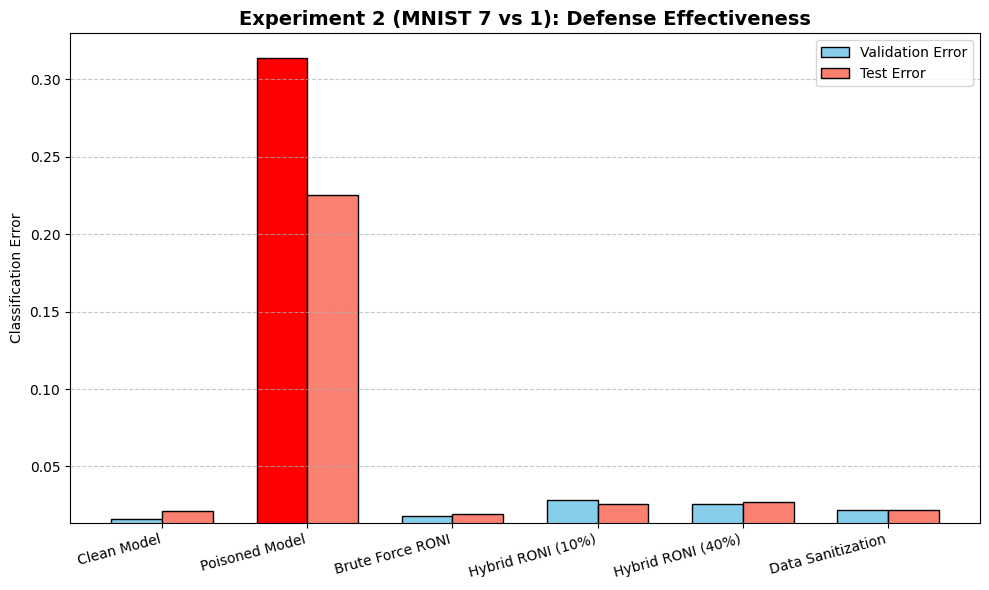


EXPERIMENT: MNIST (9 vs 8)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.1773
Validation Error      : 0.0500
Test Hinge Loss       : 0.1587
Test Error            : 0.0373


Injecting 5 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 0.9261
Validation Error      : 0.3300
Test Hinge Loss       : 0.7934
Test Error            : 0.3122


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 6 | Poison Removed (Actual): 3/5 | Clean Removed (Mistake): 3/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.2565
Validation Error      : 0.0800
Test Hinge Loss       : 0.2211
Test Error            : 0.0661


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 10 | Poison Removed (Actual): 5/5 | Clean Removed (Mistake): 5/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.1878
Validation Error      : 0.0520
Test

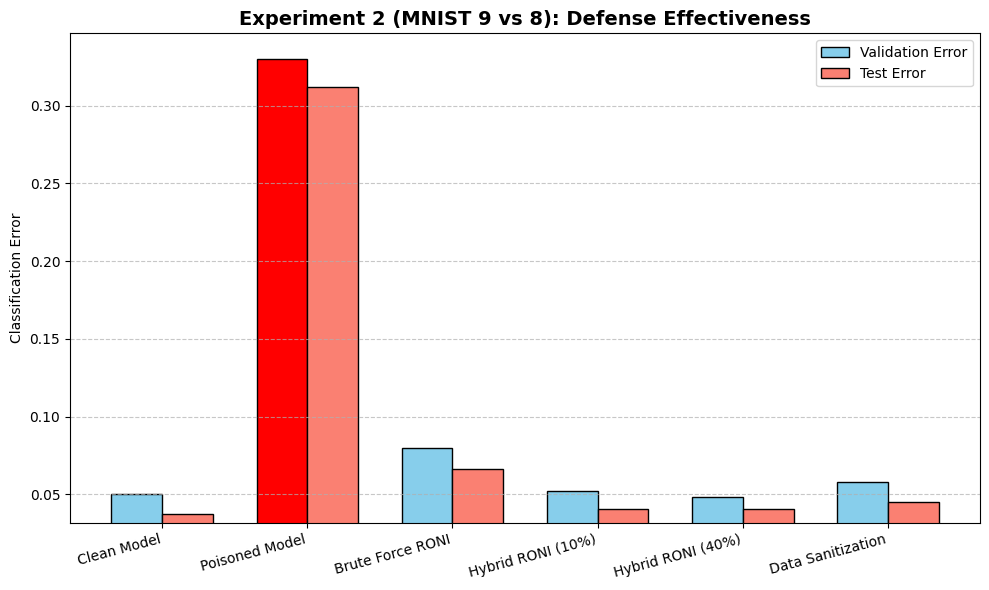


EXPERIMENT: MNIST (4 vs 0)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.0672
Validation Error      : 0.0080
Test Hinge Loss       : 0.0740
Test Error            : 0.0087


Injecting 5 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 0.7549
Validation Error      : 0.3480
Test Hinge Loss       : 0.6252
Test Error            : 0.2706


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 7 | Poison Removed (Actual): 2/5 | Clean Removed (Mistake): 5/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.0866
Validation Error      : 0.0180
Test Hinge Loss       : 0.0848
Test Error            : 0.0153


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 10 | Poison Removed (Actual): 5/5 | Clean Removed (Mistake): 5/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.0718
Validation Error      : 0.0060
Test

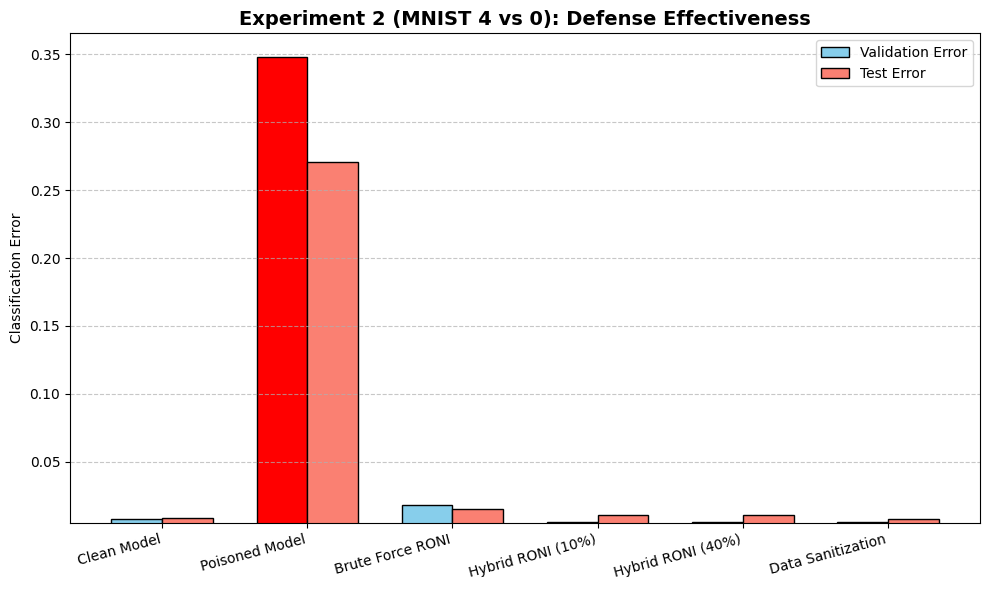

In [5]:
run_mnist_defenses(7, 1)
run_mnist_defenses(9, 8)
run_mnist_defenses(4, 0)

### Experiment with 20 poison points


EXPERIMENT: MNIST (7 vs 1)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.0884
Validation Error      : 0.0160
Test Hinge Loss       : 0.0816
Test Error            : 0.0213


Injecting 20 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 0.9669
Validation Error      : 0.3620
Test Hinge Loss       : 0.8330
Test Error            : 0.3014


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 9 | Poison Removed (Actual): 3/20 | Clean Removed (Mistake): 6/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.3912
Validation Error      : 0.1480
Test Hinge Loss       : 0.4159
Test Error            : 0.1632


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 11 | Poison Removed (Actual): 6/20 | Clean Removed (Mistake): 5/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.4563
Validation Error      : 0.1800
T

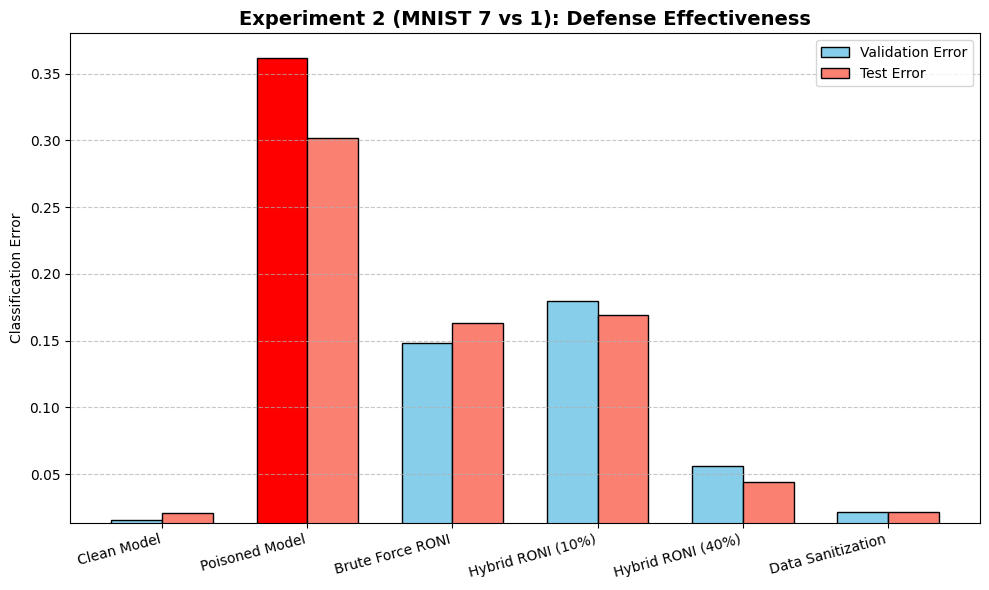


EXPERIMENT: MNIST (9 vs 8)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.1773
Validation Error      : 0.0500
Test Hinge Loss       : 0.1587
Test Error            : 0.0373


Injecting 20 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 1.4720
Validation Error      : 0.4640
Test Hinge Loss       : 1.2404
Test Error            : 0.4115


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 15 | Poison Removed (Actual): 6/20 | Clean Removed (Mistake): 9/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.7397
Validation Error      : 0.2700
Test Hinge Loss       : 0.6724
Test Error            : 0.2582


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 12 | Poison Removed (Actual): 8/20 | Clean Removed (Mistake): 4/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.8575
Validation Error      : 0.3220


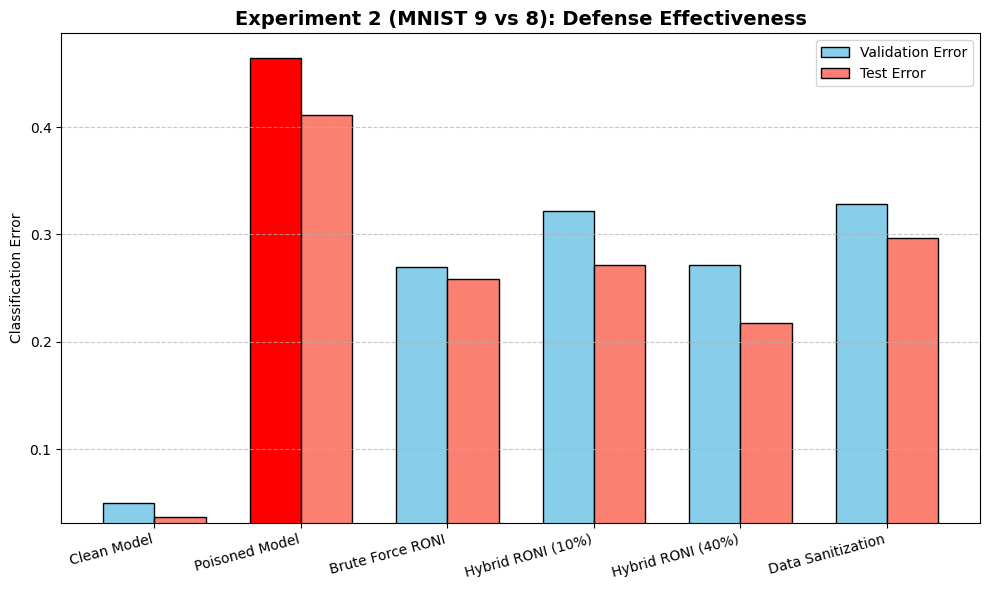


EXPERIMENT: MNIST (4 vs 0)
Loading MNIST dataset (this may take a moment on first run)...
--- Stats for Clean Model ---
Validation Hinge Loss : 0.0672
Validation Error      : 0.0080
Test Hinge Loss       : 0.0740
Test Error            : 0.0087


Injecting 20 poison points...
--- Stats for Poisoned Model ---
Validation Hinge Loss : 1.4604
Validation Error      : 0.5800
Test Hinge Loss       : 1.2737
Test Error            : 0.5127


Running Brute Force RONI defense (leave-one-out retraining)...
[Brute Force RONI] Total Removed: 11 | Poison Removed (Actual): 4/20 | Clean Removed (Mistake): 7/100
--- Stats for Brute Force RONI ---
Validation Hinge Loss : 0.3710
Validation Error      : 0.1500
Test Hinge Loss       : 0.3543
Test Error            : 0.1468


Running Hybrid RONI (10%) defense...
[Hybrid RONI (10%)] Total Removed: 10 | Poison Removed (Actual): 6/20 | Clean Removed (Mistake): 4/100
--- Stats for Hybrid RONI (10%) ---
Validation Hinge Loss : 0.6928
Validation Error      : 0.3060


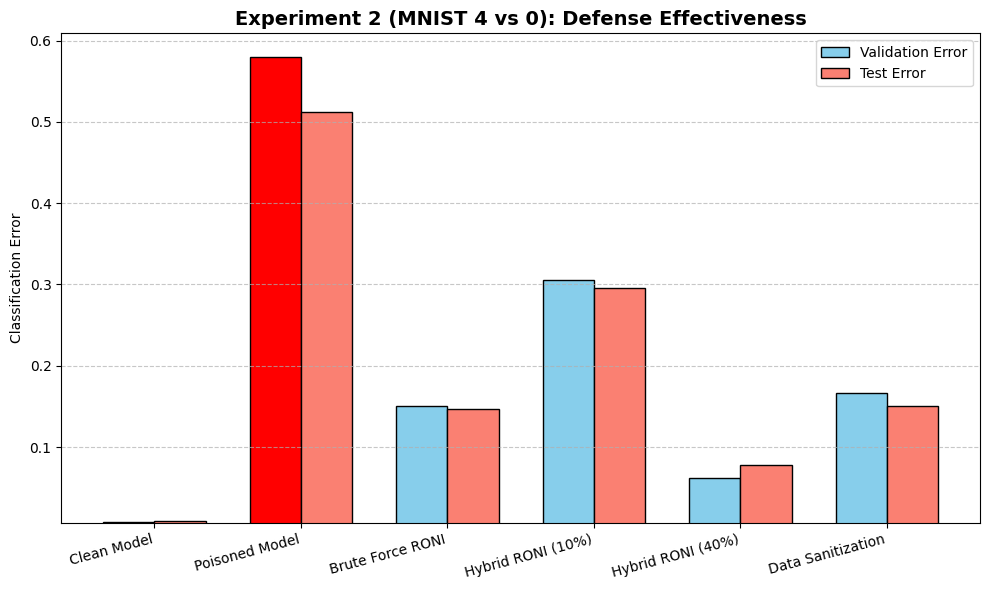

In [6]:
run_mnist_defenses(7, 1, n_poison=20)
run_mnist_defenses(9, 8, n_poison=20)
run_mnist_defenses(4, 0, n_poison=20)